In [1]:
pip install pandas

In [2]:
import pandas as pd

df = pd.read_csv('noisy_14.txt', sep=' ', header=None, names=['x','y'])
df.head()

,x,y
0,-100.000000,1.651063
1,-99.979998,16.006021
2,-99.959996,2.636980
3,-99.939994,-19.672701
4,-99.919992,-5.570048


In [3]:
sdf = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [4]:
import numpy as np
x = sdf['x'].to_numpy()
y = sdf['y'].to_numpy()
print(x,y)

[ 25.05250525  -6.31063106 -65.37653765 ...   7.81078108 -82.79827983
  45.41454145] [  7.65527386  -8.36048657 103.87892924 ... -15.12642732  95.32035194
  51.82884689]


In [5]:
n = len(x)
t = int(0.6 * n)
v = int(0.8 * n)

x_train, y_train = x[:t], y[:t]
x_val, y_val = x[t:v], y[t:v]
x_test, y_test = x[v:], y[v:]

print(len(x_train), len(x_val), len(x_test))

6000 2000 2000


In [6]:
import numpy as np

def des_mat(x, deg):
    n = len(x)
    phi = np.zeros((n, deg + 1))
    for j in range(deg + 1):
        phi[:, j] = x ** j
    return phi

In [7]:
def weights(phi, t):
    w = np.linalg.inv(phi.T @ phi) @ (phi.T @ t)
    return w

In [8]:
def mse(phi, w, t):
    pred = phi @ w
    return np.mean((pred - t) ** 2)

In [9]:
deg_max = 25
degrees = list(range(1, deg_max + 1))
train_err = []
val_err = []

for deg in degrees:
    phi_train = des_mat(x_train, deg)
    phi_val = des_mat(x_val, deg)

    w = weights(phi_train, y_train)

    train_mse = mse(phi_train, w, y_train)
    val_mse = mse(phi_val, w, y_val)

    train_err.append(train_mse)
    val_err.append(val_mse)

    print(f"Degree {deg}: train MSE = {train_mse:.4f}, val MSE = {val_mse:.4f}")

Degree 1: train MSE = 1349.3204, val MSE = 1296.6070
Degree 2: train MSE = 1347.0067, val MSE = 1288.8405
Degree 3: train MSE = 1097.2586, val MSE = 1096.4393
Degree 4: train MSE = 815.5762, val MSE = 843.8868
Degree 5: train MSE = 748.8902, val MSE = 773.0205
Degree 6: train MSE = 573.8951, val MSE = 594.2788
Degree 7: train MSE = 533.3660, val MSE = 564.8483
Degree 8: train MSE = 327.8416, val MSE = 321.7239
Degree 9: train MSE = 191.2108, val MSE = 183.2897
Degree 10: train MSE = 191.0017, val MSE = 183.4023
Degree 11: train MSE = 190.8171, val MSE = 183.4350
Degree 12: train MSE = 190.8068, val MSE = 183.5194
Degree 13: train MSE = 190.7726, val MSE = 183.7199
Degree 14: train MSE = 190.7656, val MSE = 183.6752
Degree 15: train MSE = 190.7225, val MSE = 183.8289
Degree 16: train MSE = 190.7163, val MSE = 183.7880
Degree 17: train MSE = 190.6718, val MSE = 183.7382
Degree 18: train MSE = 190.6689, val MSE = 183.7286
Degree 19: train MSE = 190.6555, val MSE = 183.7641
Degree 20: trai

In [10]:
best_deg = 9

phi_train = des_mat(x_train, best_deg)
w_best = weights(phi_train, y_train)

phi_test = des_mat(x_test, best_deg)
test_mse = mse(phi_test, w_best, y_test)

print(f"Final degree: {best_deg}")
print(f"Test MSE: {test_mse:.4f}")

Final degree: 9
Test MSE: 175.3551


In [11]:
for i, wi in enumerate(w_best):
    print(f"w_{i}: {wi}")

w_0: -16.11088113600465
w_1: -2.373259166653895
w_2: 0.11086348894686227
w_3: 0.0021536060493689557
w_4: -4.473955305903197e-05
w_5: -7.961704572266931e-07
w_6: 6.444114477475402e-09
w_7: 1.0878768732054263e-10
w_8: -3.0854260827678426e-13
w_9: -4.847117970861827e-15


In [12]:
pip install matplotlib

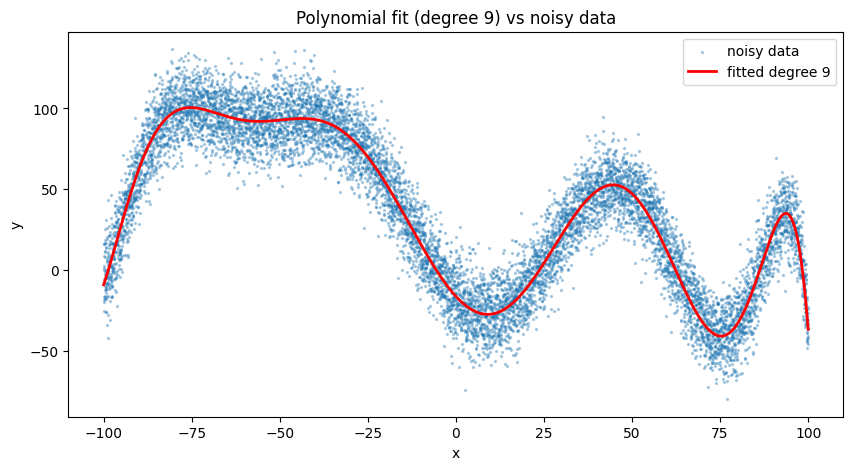

In [13]:
import matplotlib.pyplot as plt

x_line = np.linspace(x.min(), x.max(), 500)
phi_line = des_mat(x_line, best_deg)
y_line = phi_line @ w_best

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=2, alpha=0.3, label="noisy data")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"fitted degree {best_deg}")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Polynomial fit (degree {best_deg}) vs noisy data")
plt.legend()
plt.savefig("fitted_curve.png", dpi=150, bbox_inches='tight')
plt.show()

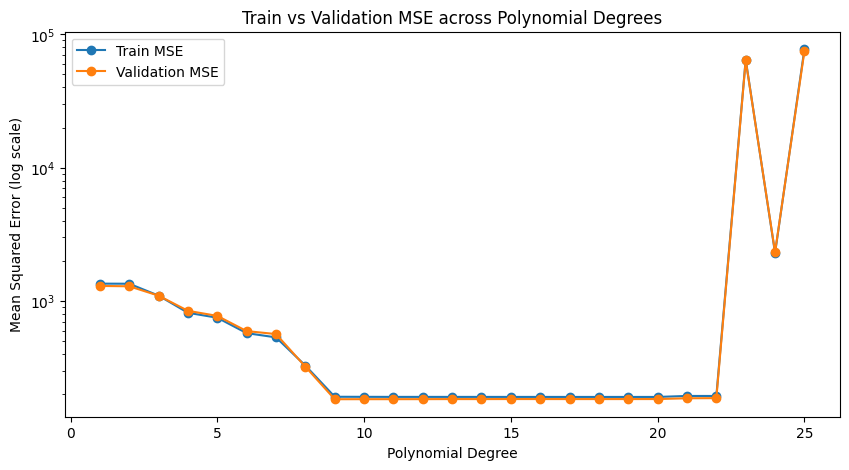

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_err, marker='o', label="Train MSE")
plt.plot(degrees, val_err, marker='o', label="Validation MSE")
plt.yscale('log')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (log scale)")
plt.title("Train vs Validation MSE across Polynomial Degrees")
plt.legend()
plt.savefig("mse_vs_degree.png", dpi=150, bbox_inches='tight')
plt.show()

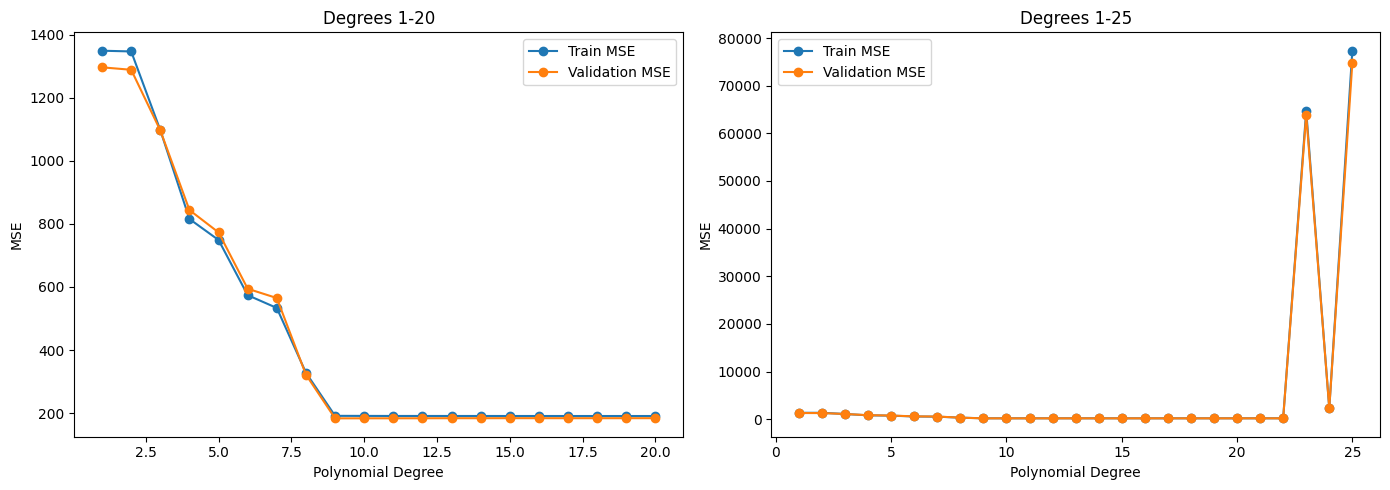

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees[:20], train_err[:20], marker='o', label="Train MSE")
axes[0].plot(degrees[:20], val_err[:20], marker='o', label="Validation MSE")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("Degrees 1-20")
axes[0].legend()

axes[1].plot(degrees, train_err, marker='o', label="Train MSE")
axes[1].plot(degrees, val_err, marker='o', label="Validation MSE")
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("MSE")
axes[1].set_title("Degrees 1-25")
axes[1].legend()

plt.tight_layout()
plt.savefig("mse_vs_degree_twopanel.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
best_degree = 9
phi_train_best = des_mat(x_train, best_degree)
w_best = weights(phi_train_best, y_train)

for i, wi in enumerate(w):
    print(f"w_{i}: {wi:.2e}")

w_0: -5.47e+02
w_1: -2.33e+00
w_2: 3.88e-01
w_3: 1.82e-03
w_4: -1.16e-04
w_5: 2.23e-08
w_6: 2.98e-08
w_7: -8.64e-10
w_8: -1.51e-11
w_9: 6.12e-13
w_10: 8.23e-15
w_11: -2.21e-16
w_12: -3.13e-18
w_13: 4.48e-20
w_14: 8.04e-22
w_15: -4.20e-24
w_16: -1.39e-25
w_17: -1.50e-28
w_18: 1.59e-29
w_19: 8.61e-32
w_20: -1.15e-33
w_21: -9.70e-36
w_22: 4.73e-38
w_23: 5.03e-40
w_24: -8.49e-43
w_25: -1.04e-44
